In [2]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt

In [312]:
# ds = xr.load_dataset('ocean_dunex_19_grd_32_frc.nc')
ds = xr.load_dataset('ocean_dunex_56.nc').isel(ocean_time=-1)
# dss = xr.load_dataset('ocean_dunex_19-1.nc').isel(ocean_time=-1)

# hs = ds.Hwave
# del ds
# ub = ds.ubar
# del ds

/Users/mleclair/.pyenv/versions/3.12.1/lib/python3.12/site-packages/xarray/coding/times.py:995: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/mleclair/.pyenv/versions/3.12.1/lib/python3.12/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/Users/mleclair/.pyenv/versions/3.12.1/lib/python3.12/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()


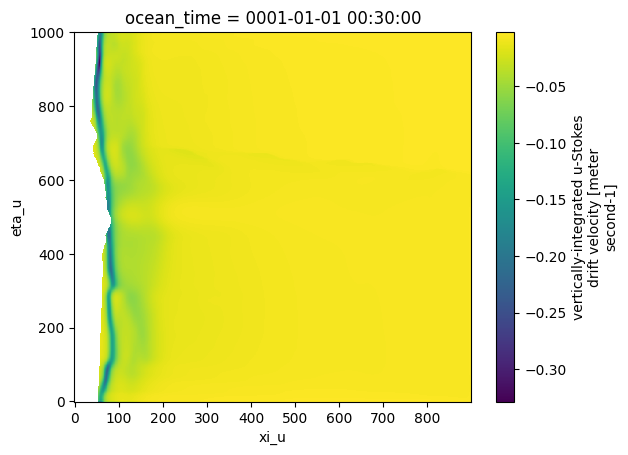

In [314]:
ds.ubar_stokes.plot()

/Users/mleclair/.pyenv/versions/3.12.1/lib/python3.12/site-packages/matplotlib/axes/_axes.py:6834: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/Users/mleclair/.pyenv/versions/3.12.1/lib/python3.12/site-packages/matplotlib/axes/_axes.py:6835: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


(array([[   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        ...,
        [1001.,    0.,    0., ...,    0.,    0.,    0.],
        [1001.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0., 1001.]]),
 array([0.        , 0.06066582, 0.12133164, 0.18199747, 0.24266329,
        0.30332911, 0.36399493, 0.42466075, 0.48532658, 0.5459924 ,
        0.60665822]),
 <a list of 901 BarContainer objects>)

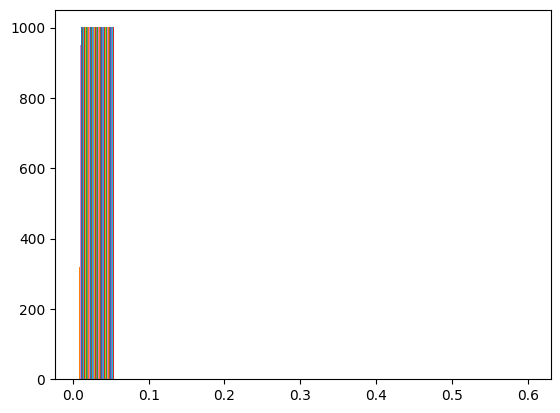

In [301]:
plt.hist(ds.Hwave.values)

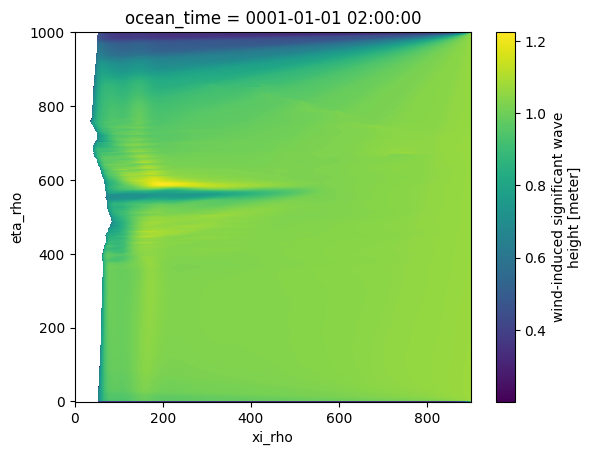

In [130]:
dss.Hwave.plot()

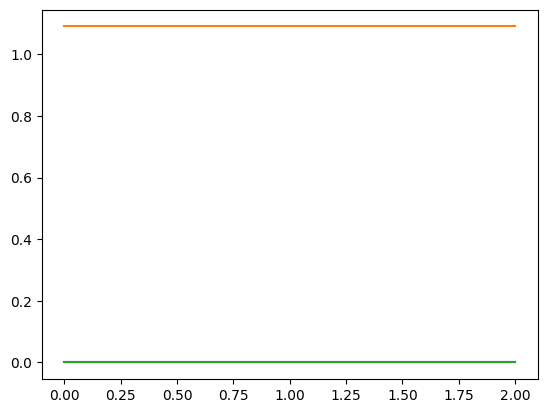

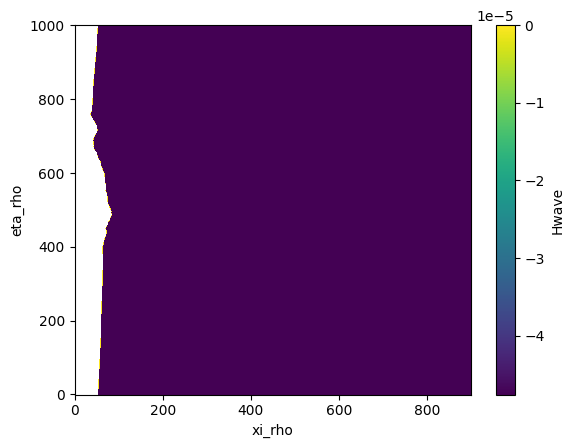

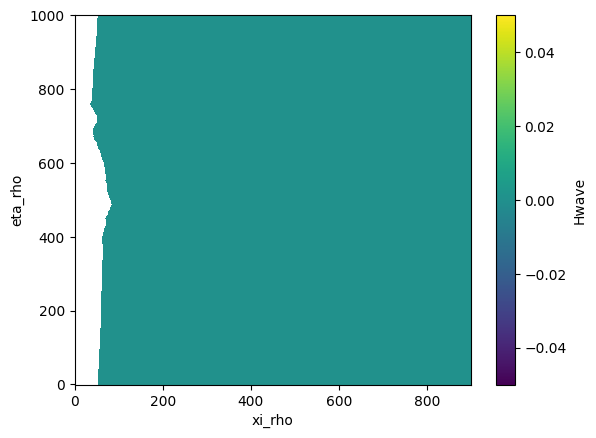

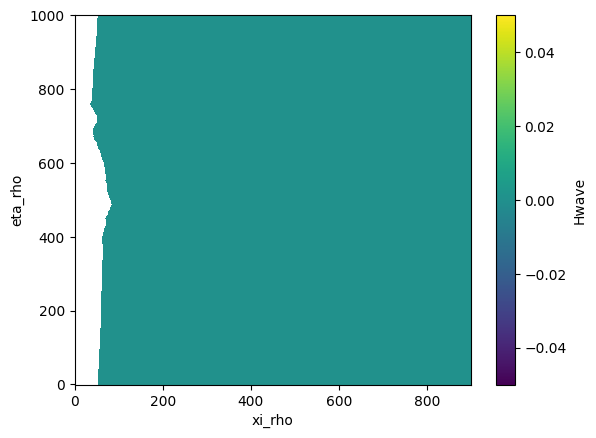

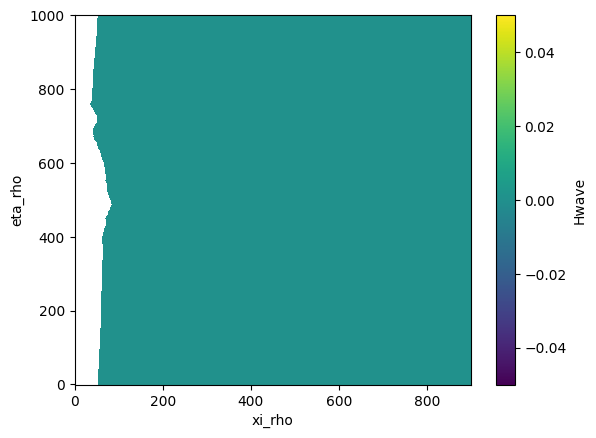

In [25]:
# Looking at convergence. Are we running the simulation long enough?
# First impression is yes for Hs
plt.plot(hs.ocean_time.dt.hour, hs.mean(dim='eta_rho').mean(dim='xi_rho'))
plt.plot(hs.ocean_time.dt.hour, hs.max(dim='eta_rho').max(dim='xi_rho'))
plt.plot(hs.ocean_time.dt.hour, hs.min(dim='eta_rho').min(dim='xi_rho'))

for i in range(4):
    plt.figure()
    (hs.isel(ocean_time=i+1) - hs.isel(ocean_time=i)).plot()

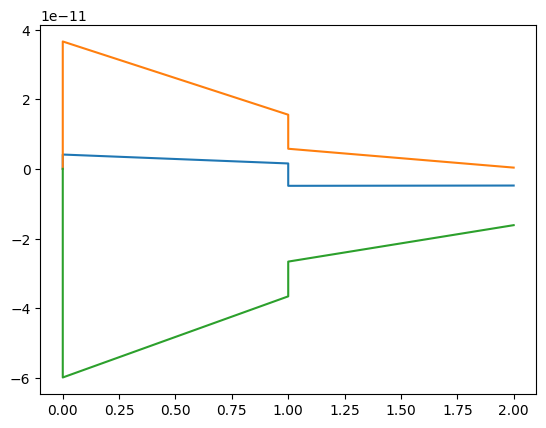

In [27]:
# Convergence is less clear in currents especially with the timestep for history
# I should do a run with just the vars I really care about to see if it's actually approaching
plt.plot(ub.ocean_time.dt.hour, ub.mean(dim='eta_u').mean(dim='xi_u'))
plt.plot(ub.ocean_time.dt.hour, ub.max(dim='eta_u').max(dim='xi_u'))
plt.plot(ub.ocean_time.dt.hour, ub.min(dim='eta_u').min(dim='xi_u'))


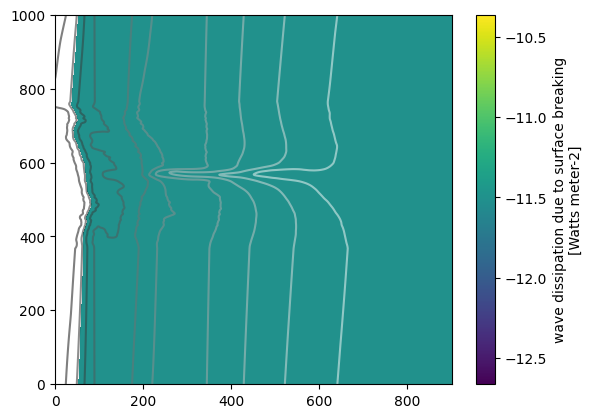

In [31]:
plt.pcolormesh(ds.xi_rho, ds.eta_rho, np.log(ds.Dissip_break + 1e-5))
plt.colorbar(label=f'{ds.Dissip_break.long_name}\n[{ds.Dissip_break.units}]')
plt.contour(ds.xi_rho, ds.eta_rho, ds.h, cmap='grey', levels=np.arange(10), alpha=0.5)

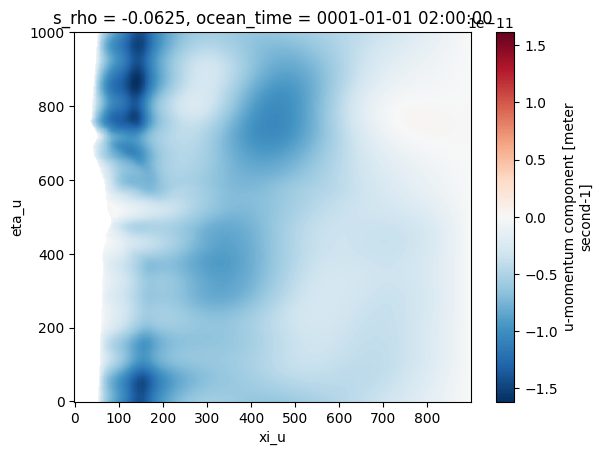

In [30]:
ds.u.isel(s_rho=-1).plot()

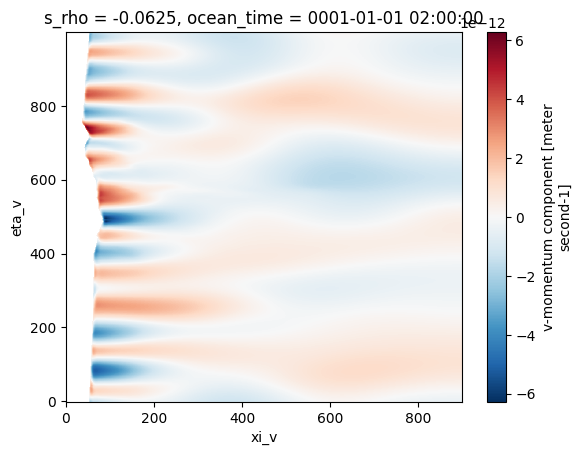

In [32]:
ds.v.isel(s_rho=-1).plot()

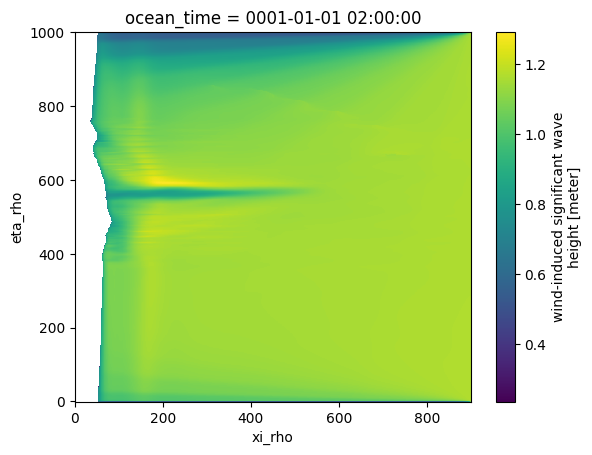

In [297]:
dss.Hwave.plot()
# plt.ylim([400, 800])

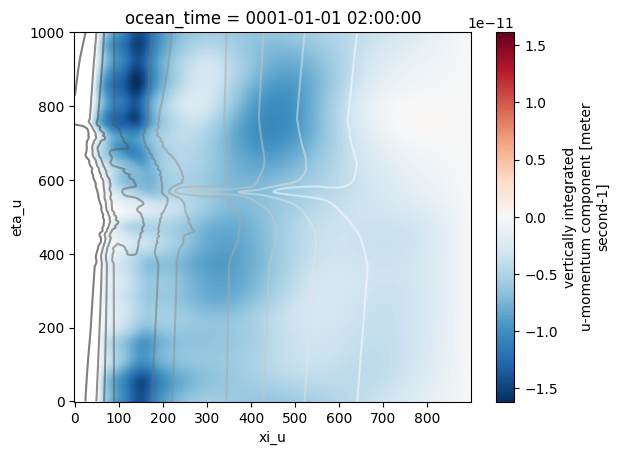

In [34]:
ds.ubar.plot()
from cmocean import cm 
plt.contour(ds.xi_rho, ds.eta_rho, ds.h, cmap='grey', levels=np.arange(10), alpha=0.5)

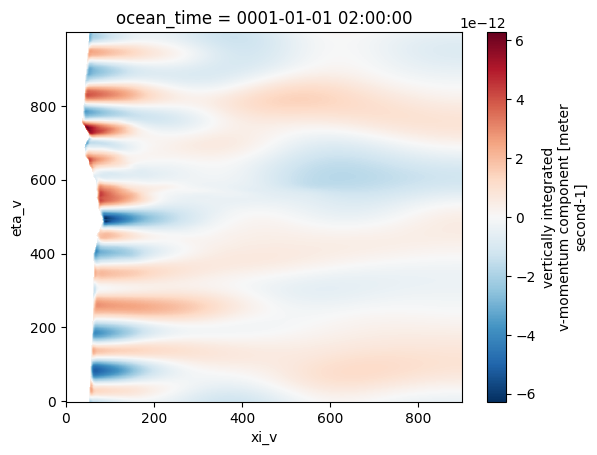

In [35]:
ds.vbar.plot()

(400.0, 800.0)

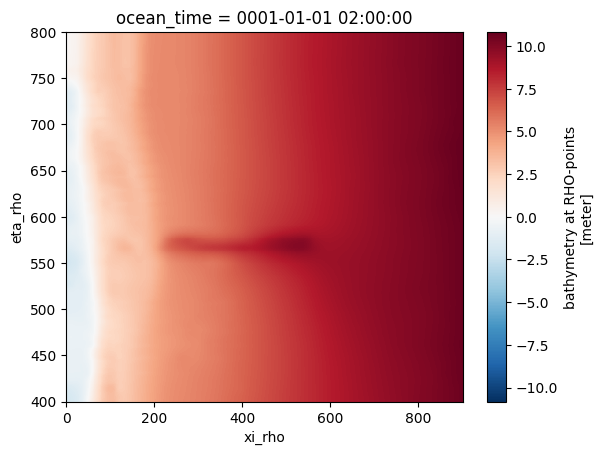

In [36]:
ds.h.plot()
plt.ylim([400, 800])

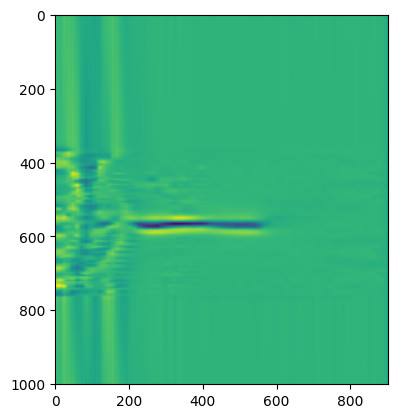

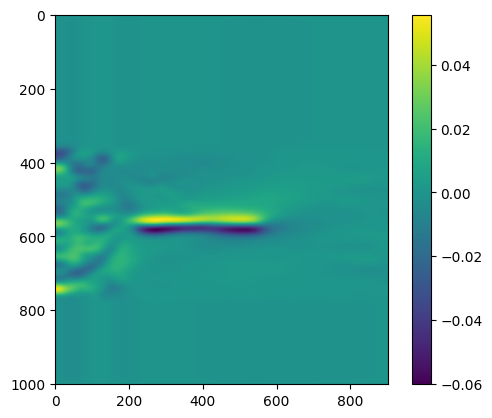

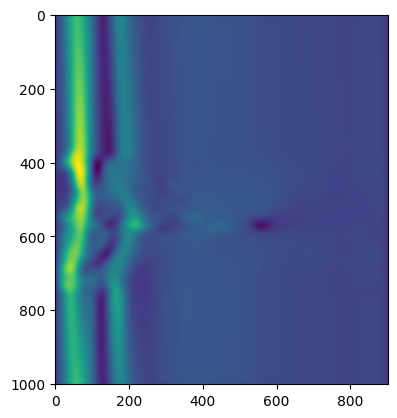

In [37]:
from scipy import ndimage
h = ndimage.gaussian_filter(ds.h, sigma=10)
plt.imshow(h-ds.h)
plt.figure()
dx, dy = np.gradient(h)
plt.imshow(dx)
plt.colorbar()
plt.figure()
plt.imshow(dy)

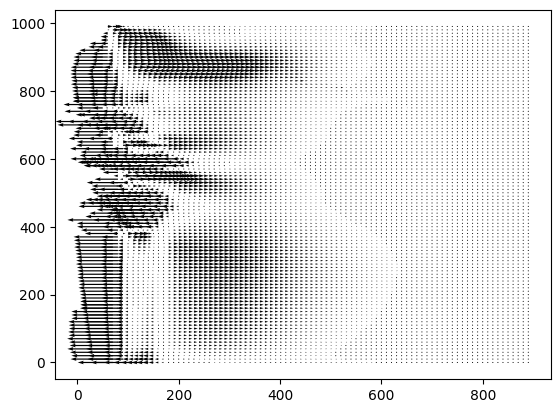

In [158]:
s = 10
i = -1
plt.quiver(
    *np.meshgrid(ds.xi_u[::s], ds.eta_v[::s]), 
    dss.u.isel(s_rho=i)[:-1:s, ::s], ds.v.isel(s_rho=i)[::s, :-1:s],
    # c=np.sqrt(
    # (ds.u.isel(s_rho=-1).values**2)[:-1, :] +
    # (ds.v.isel(s_rho=-1).values**2)[:, :-1]),
    # scale=20
    )

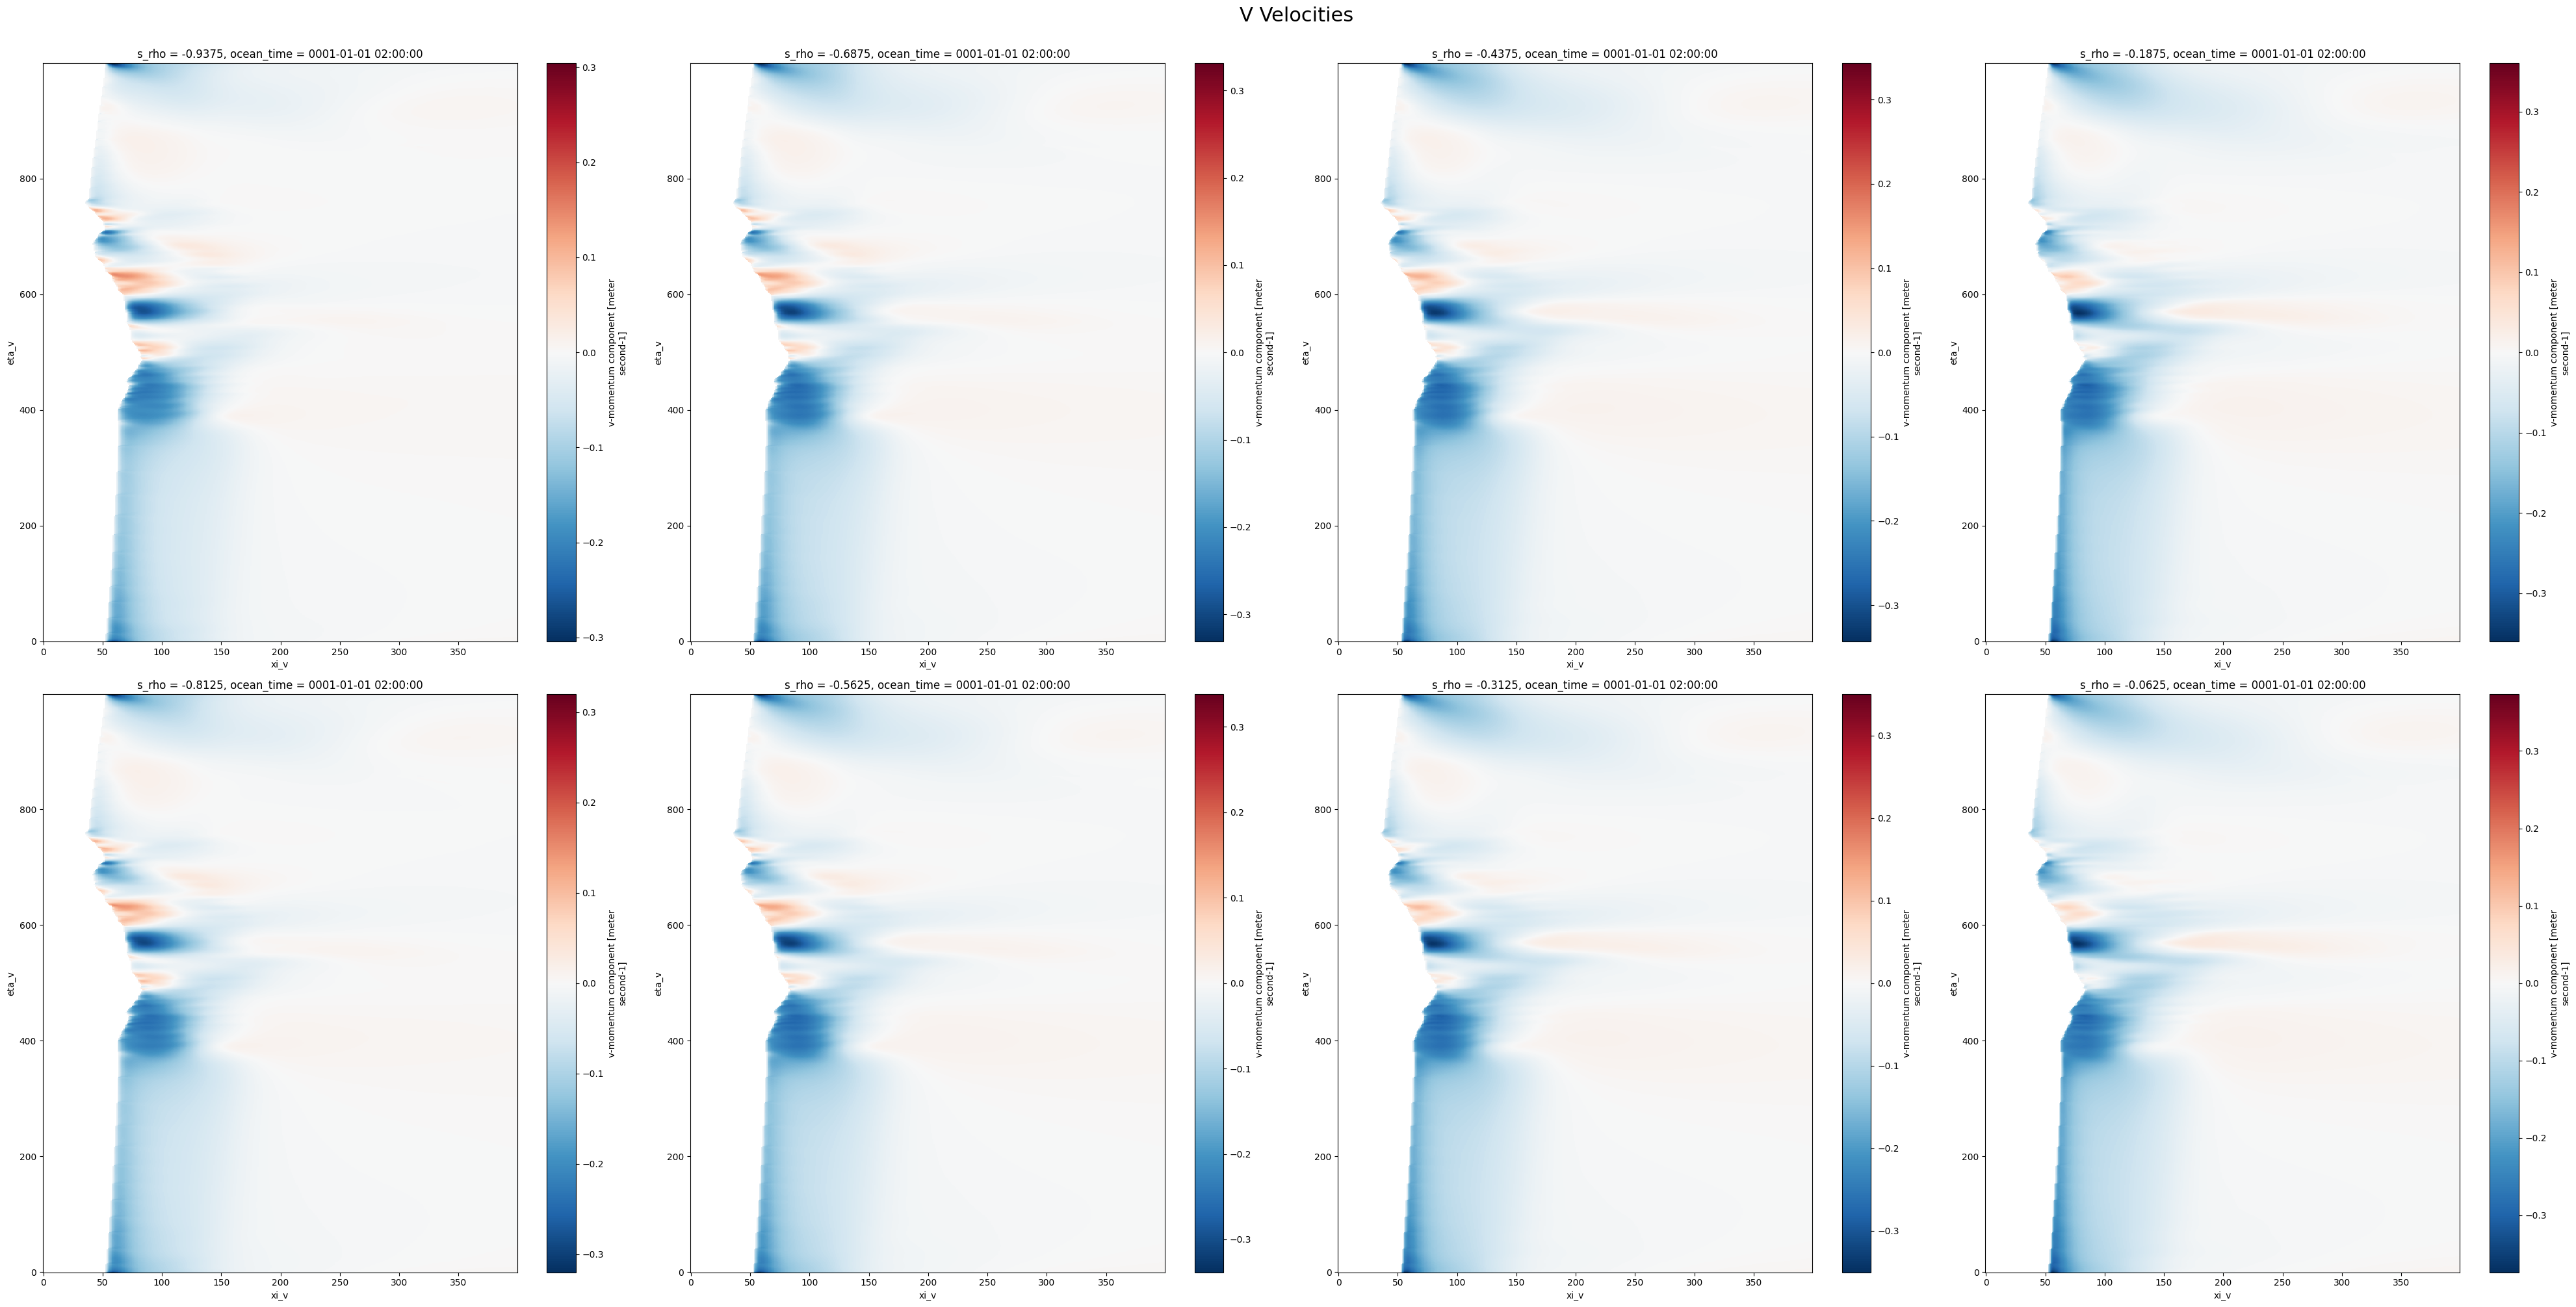

In [304]:
# fig, axs = plt.subplots(8, 1, figsize=(10, 40))
# for s in range(8):
#         dss.tke.isel(s_w=-s)[:, :400].plot(ax=axs[s])
#         # ds.u.isel(s_rho=s).plot(ax=axs[s//2, s%2])
#     # plt.figure()
fig, axs = plt.subplots(2, 4, figsize=(40, 20))
for s in range(8):
        # ds.tke.isel(s_w=s).plot(ax=axs[s//2, s%2])
        dss.v.isel(s_rho=s)[:, :400].plot(ax=axs[s%2, s//2])
    # plt.figure()
fig.suptitle('V Velocities', y=1.003, size=22)
plt.tight_layout()


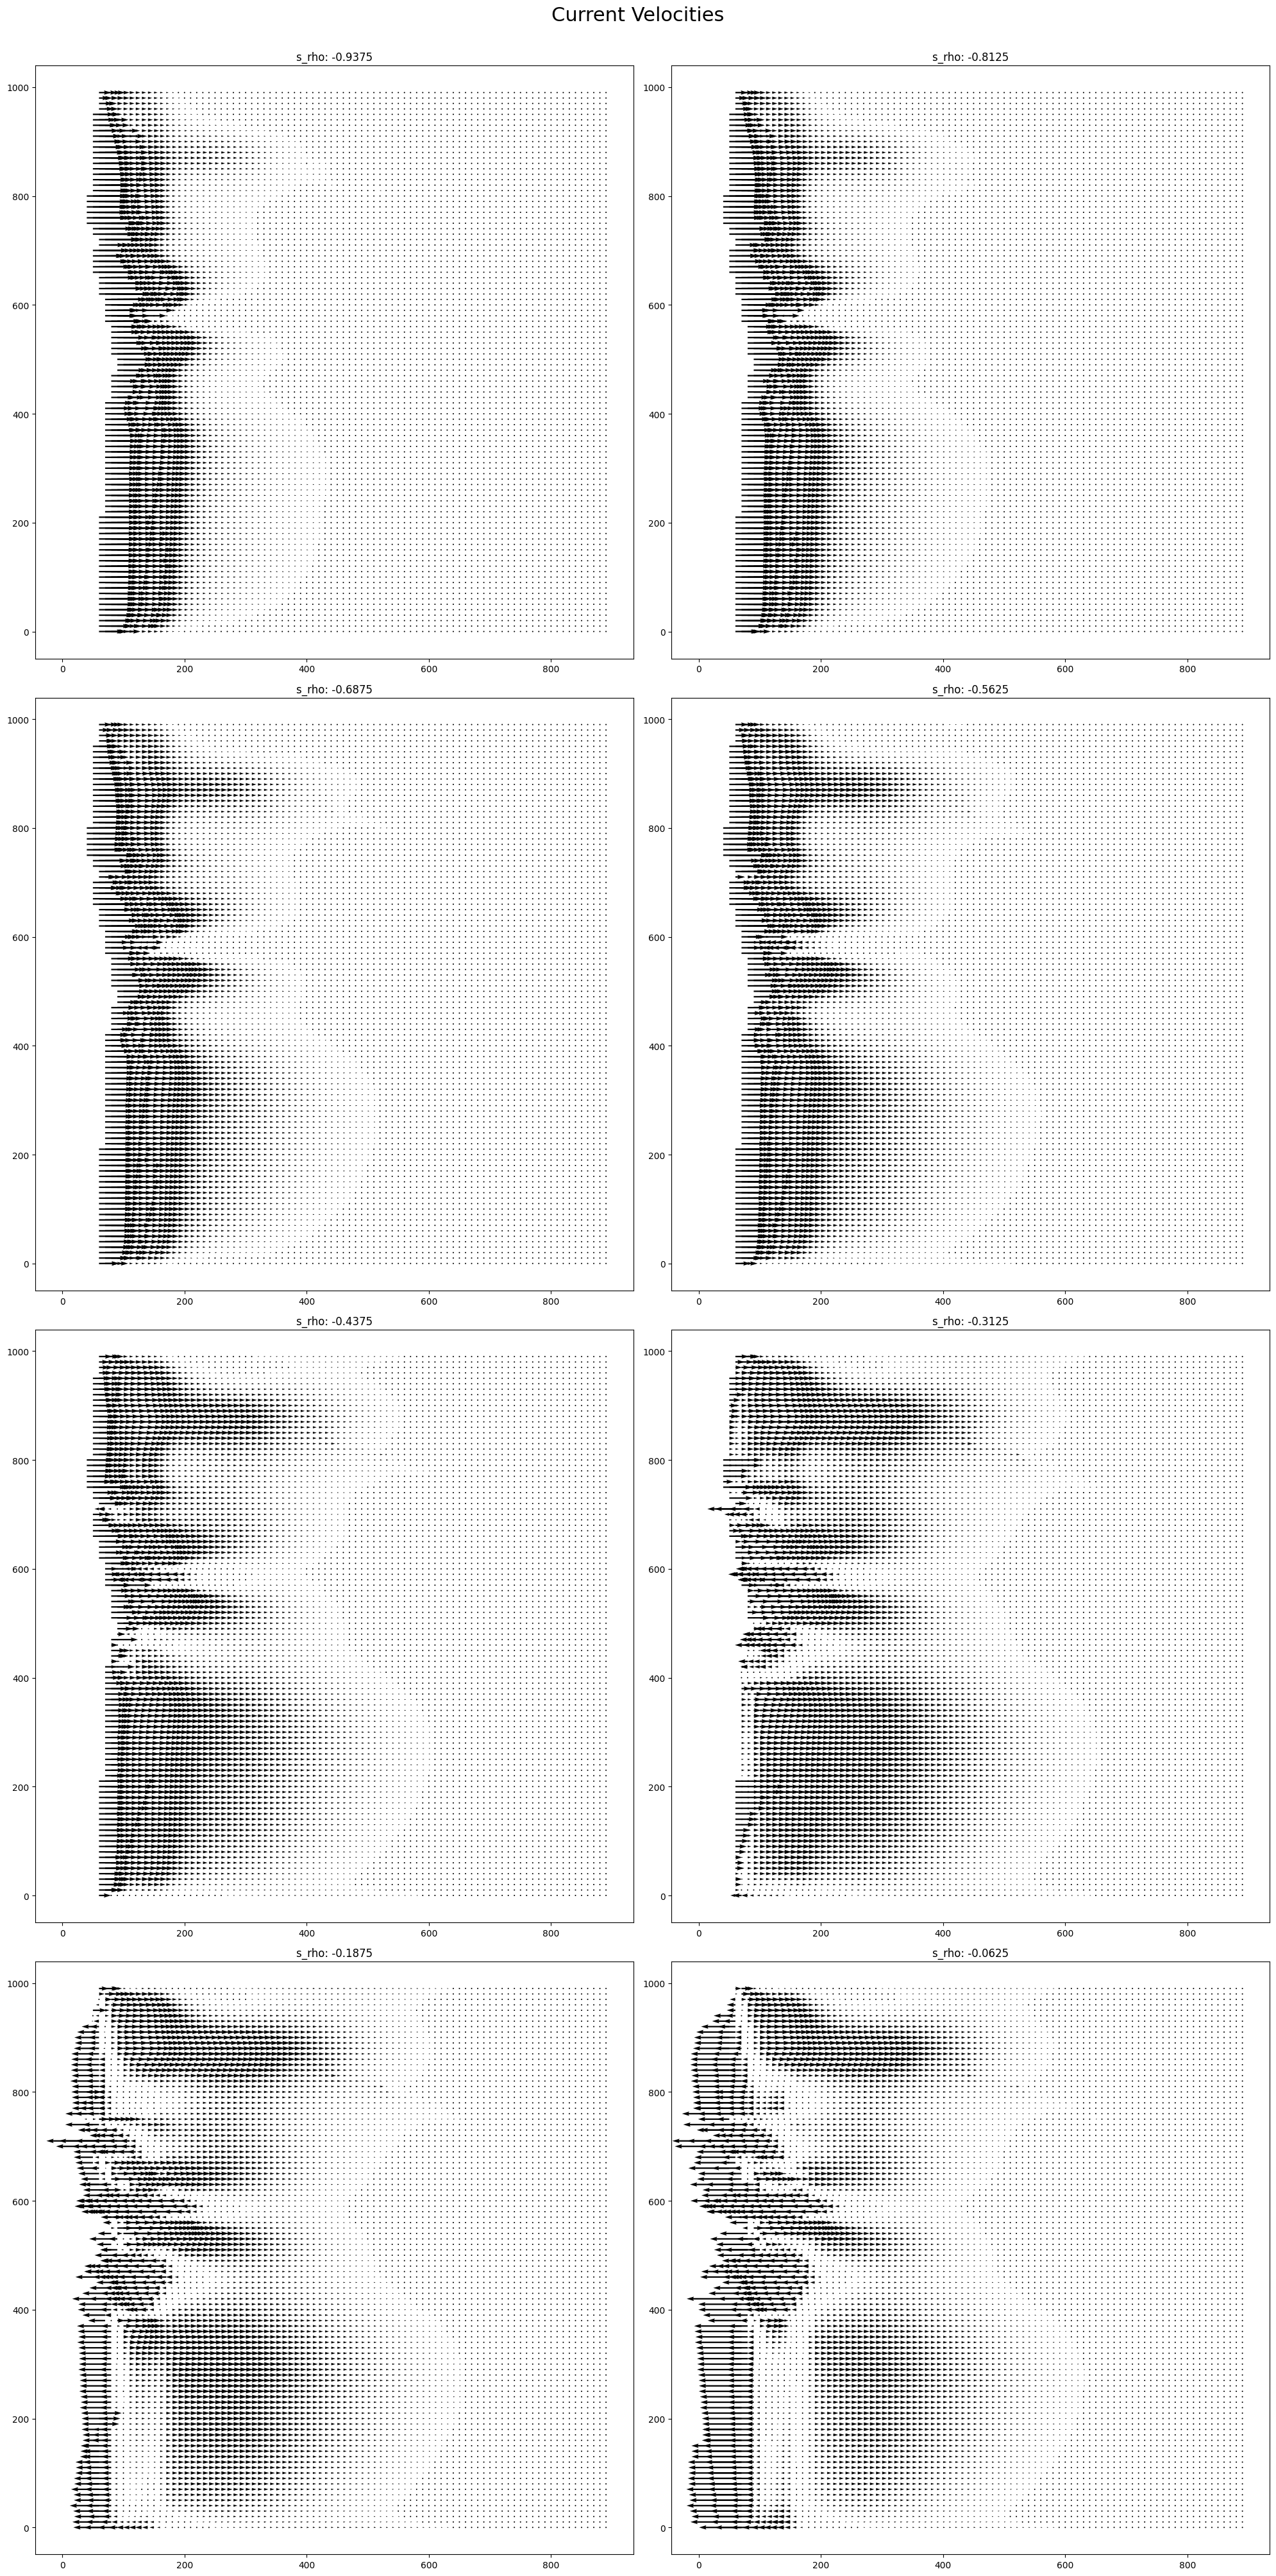

In [182]:
fig, axs = plt.subplots(4, 2, figsize=(20, 40))
s=10
for ss in range(8):
    axs[ss//2, ss%2].quiver(
        *np.meshgrid(ds.xi_u[::s], ds.eta_v[::s]), 
        dss.u.isel(s_rho=ss)[:-1:s, ::s], ds.v.isel(s_rho=ss)[::s, :-1:s],
    ) 
    axs[ss//2, ss%2].set_title(f's_rho: {dss.s_rho[ss].item()}')
fig.suptitle('Current Velocities', y=1.003, size=22)
plt.tight_layout()


In [183]:
ds.s_rho

<xarray.DataArray 's_rho' (s_rho: 8)> Size: 64B
array([-0.9375, -0.8125, -0.6875, -0.5625, -0.4375, -0.3125, -0.1875, -0.0625])
Coordinates:
  * s_rho       (s_rho) float64 64B -0.9375 -0.8125 -0.6875 ... -0.1875 -0.0625
    ocean_time  object 8B 0001-01-01 02:00:00
Attributes:
    long_name:      S-coordinate at RHO-points
    valid_min:      -1.0
    valid_max:      0.0
    positive:       up
    standard_name:  ocean_s_coordinate_g1
    formula_terms:  s: s_rho C: Cs_r eta: zeta depth: h depth_c: hc
    field:          s_rho, scalar

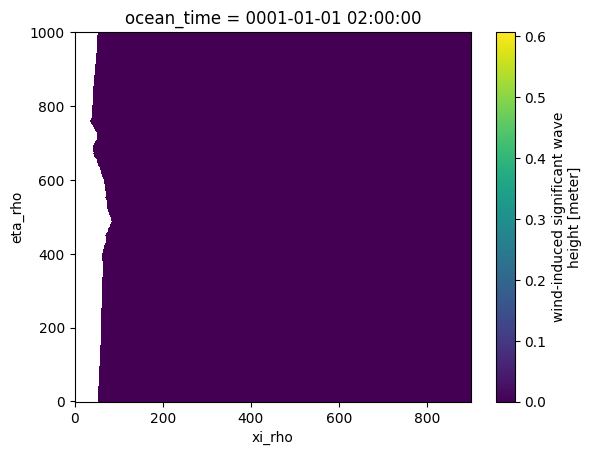

In [308]:
ds.Hwave.plot()

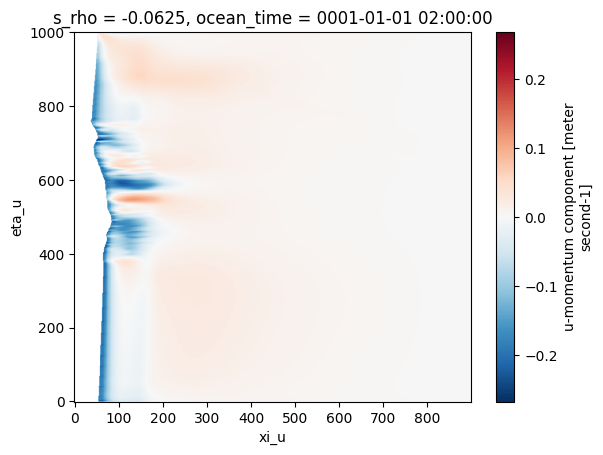

In [202]:
dss.u.isel(s_rho=-1).plot()

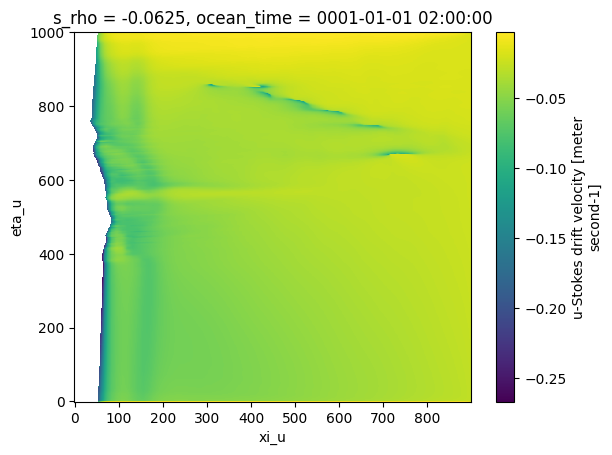

In [201]:
dss.u_stokes.isel(s_rho=-1).plot()

/Users/mleclair/.pyenv/versions/3.12.1/lib/python3.12/site-packages/xarray/core/computation.py:825: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


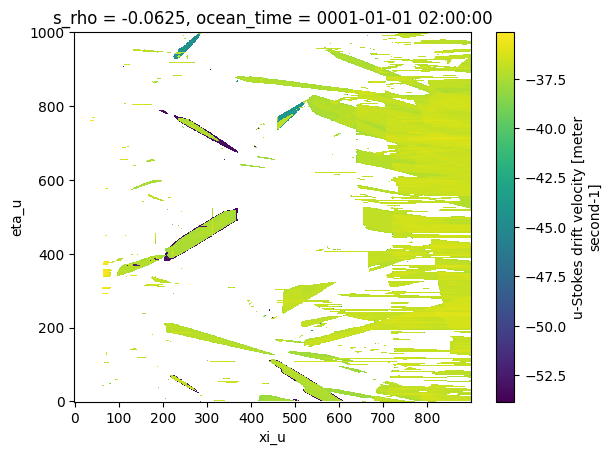

In [305]:

np.log10(np.abs(ds.u_stokes.isel(s_rho=-1))).plot()

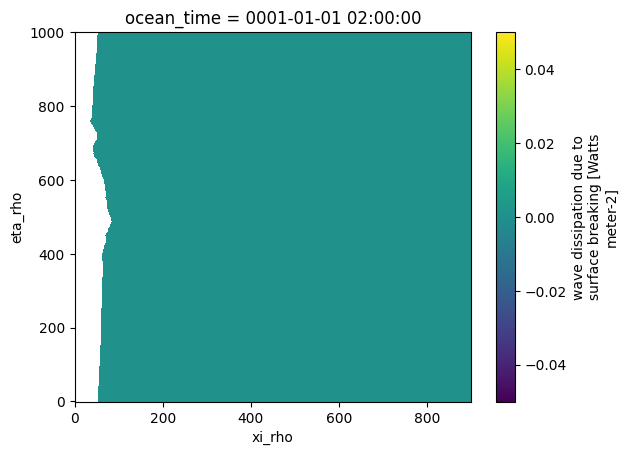

In [306]:
ds.Dissip_break.plot()

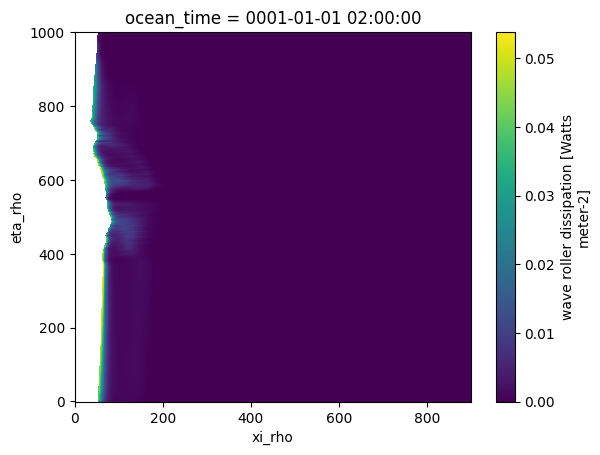

In [232]:
dss.Dissip_roller.plot()

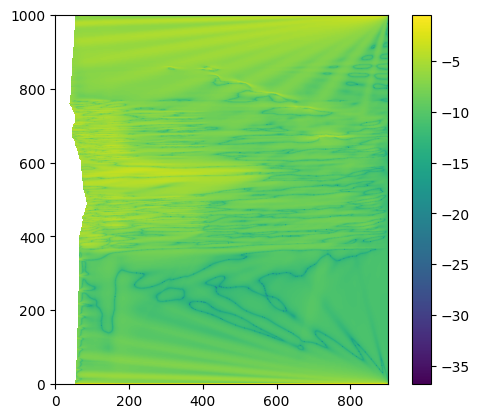

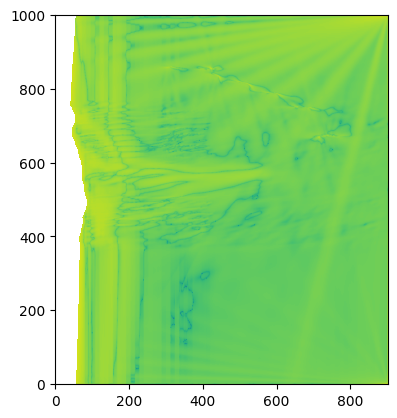

In [231]:
plt.imshow(np.log(np.abs((np.gradient(dss.Hwave)[0])+1e-16)), origin='lower')
plt.colorbar()
plt.figure()
plt.imshow(np.log(np.abs((np.gradient(dss.Hwave)[1])+1e-16)), origin='lower')


In [210]:
np.gradient(dss.Hwave)

[array([[        nan,         nan,         nan, ...,  0.18461728,
          0.11169088, -0.00044823],
        [        nan,         nan,         nan, ...,  0.09575182,
          0.05804813, -0.00113046],
        [        nan,         nan,         nan, ...,  0.00434381,
          0.00268751, -0.00120574],
        ...,
        [        nan,         nan,         nan, ..., -0.07364851,
         -0.04474378,  0.00229579],
        [        nan,         nan,         nan, ...,  0.03650653,
          0.02013016,  0.0013693 ],
        [        nan,         nan,         nan, ...,  0.18461728,
          0.11169088, -0.00044823]]),
 array([[        nan,         nan,         nan, ...,  0.06946796,
          0.09628904,  0.11525464],
        [        nan,         nan,         nan, ...,  0.00393957,
          0.00375628,  0.00311553],
        [        nan,         nan,         nan, ...,  0.00186181,
         -0.00059325, -0.00310254],
        ...,
        [        nan,         nan,         nan, ...,  

In [233]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:          (tracer: 1, s_rho: 8, s_w: 9, eta_rho: 1001, xi_rho: 901,
                      eta_u: 1001, xi_u: 900, eta_v: 1000, xi_v: 901,
                      eta_psi: 1000, xi_psi: 900)
Coordinates:
  * s_rho            (s_rho) float64 64B -0.9375 -0.8125 ... -0.1875 -0.0625
  * s_w              (s_w) float64 72B -1.0 -0.875 -0.75 ... -0.25 -0.125 0.0
    x_rho            (eta_rho, xi_rho) float64 7MB 50.0 51.0 ... 949.0 950.0
    y_rho            (eta_rho, xi_rho) float64 7MB -1.2e+03 -1.2e+03 ... 1.8e+03
    x_u              (eta_u, xi_u) float64 7MB 50.5 51.5 52.5 ... 948.5 949.5
    y_u              (eta_u, xi_u) float64 7MB -1.2e+03 -1.2e+03 ... 1.8e+03
    x_v              (eta_v, xi_v) float64 7MB 50.0 51.0 52.0 ... 949.0 950.0
    y_v              (eta_v, xi_v) float64 7MB -1.198e+03 ... 1.798e+03
    x_psi            (eta_psi, xi_psi) float64 7MB 50.5 51.5 ... 948.5 949.5
    y_psi            (eta_psi, xi_psi) float64 7MB -1.198e+03 ... 1.798e+03
    ocean_time       object 8B 0001-01-01 02:00:00
Dimensions without coordinates: tracer, eta_rho, xi_rho, eta_u, xi_u, eta_v,
                                xi_v, eta_psi, xi_psi
Data variables: (12/137)
    ntimes           int32 4B 14401
    ndtfast          int32 4B 10
    dt               float64 8B 0.5
    dtfast           float64 8B 0.05
    dstart           object 8B 0001-01-01 00:00:00
    nHIS             int32 4B 3600
    ...               ...
    Dissip_wcap      (eta_rho, xi_rho) float64 7MB nan nan nan ... 0.0 0.0 0.0
    Dissip_roller    (eta_rho, xi_rho) float64 7MB nan nan nan ... 0.0 0.0 0.0
    rollA            (eta_rho, xi_rho) float64 7MB nan nan nan ... 0.0 0.0 0.0
    zetaw            (eta_rho, xi_rho) float64 7MB nan nan ... -6.926e-92
    qsp              (eta_rho, xi_rho) float64 7MB nan nan ... -1.3e-49 -1.3e-49
    bh               (eta_rho, xi_rho) float64 7MB nan nan ... -9.456e-66
Attributes: (12/26)
    file:              ./output/ocean_dunex_his.nc
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS/TOMS history file
    title:             DUNEX
    var_info:          /gscratch/derakhti/shared/COAWST/ROMS/External/varinfo...
    ...                ...
    compiler_command:  /sw/ompi/4.1.0/bin/mpif90
    compiler_flags:    -frepack-arrays -O3 -ffast-math -O3 -ftree-vectorize -...
    tiling:            005x005
    history:           ROMS/TOMS, Version 3.8, Monday - May 27, 2024 - 10:31:...
    ana_file:          ROMS/Functionals/ana_btflux.h, ROMS/Functionals/ana_in...
    CPP_options:       DUNEX, ANA_BSFLUX, ANA_BTFLUX, ANA_INITIAL, ANA_SEDIME...

In [234]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:          (tracer: 1, s_rho: 8, s_w: 9, eta_rho: 1001, xi_rho: 901,
                      eta_u: 1001, xi_u: 900, eta_v: 1000, xi_v: 901,
                      eta_psi: 1000, xi_psi: 900)
Coordinates:
  * s_rho            (s_rho) float64 64B -0.9375 -0.8125 ... -0.1875 -0.0625
  * s_w              (s_w) float64 72B -1.0 -0.875 -0.75 ... -0.25 -0.125 0.0
    x_rho            (eta_rho, xi_rho) float64 7MB 50.0 51.0 ... 949.0 950.0
    y_rho            (eta_rho, xi_rho) float64 7MB -1.2e+03 -1.2e+03 ... 1.8e+03
    x_u              (eta_u, xi_u) float64 7MB 50.5 51.5 52.5 ... 948.5 949.5
    y_u              (eta_u, xi_u) float64 7MB -1.2e+03 -1.2e+03 ... 1.8e+03
    x_v              (eta_v, xi_v) float64 7MB 50.0 51.0 52.0 ... 949.0 950.0
    y_v              (eta_v, xi_v) float64 7MB -1.198e+03 ... 1.798e+03
    x_psi            (eta_psi, xi_psi) float64 7MB 50.5 51.5 ... 948.5 949.5
    y_psi            (eta_psi, xi_psi) float64 7MB -1.198e+03 ... 1.798e+03
    ocean_time       object 8B 0001-01-01 02:00:00
Dimensions without coordinates: tracer, eta_rho, xi_rho, eta_u, xi_u, eta_v,
                                xi_v, eta_psi, xi_psi
Data variables: (12/137)
    ntimes           int32 4B 14401
    ndtfast          int32 4B 10
    dt               float64 8B 0.5
    dtfast           float64 8B 0.05
    dstart           object 8B 0001-01-01 00:00:00
    nHIS             int32 4B 3600
    ...               ...
    Dissip_wcap      (eta_rho, xi_rho) float64 7MB nan nan nan ... 0.0 0.0 0.0
    Dissip_roller    (eta_rho, xi_rho) float64 7MB nan nan nan ... 0.0 0.0 0.0
    rollA            (eta_rho, xi_rho) float64 7MB nan nan nan ... 0.0 0.0 0.0
    zetaw            (eta_rho, xi_rho) float64 7MB nan nan ... -6.926e-92
    qsp              (eta_rho, xi_rho) float64 7MB nan nan ... -1.3e-49 -1.3e-49
    bh               (eta_rho, xi_rho) float64 7MB nan nan ... -9.456e-66
Attributes: (12/26)
    file:              ./output/ocean_dunex_his.nc
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS/TOMS history file
    title:             DUNEX
    var_info:          /gscratch/derakhti/shared/COAWST/ROMS/External/varinfo...
    ...                ...
    compiler_command:  /sw/ompi/4.1.0/bin/mpif90
    compiler_flags:    -frepack-arrays -O3 -ffast-math -O3 -ftree-vectorize -...
    tiling:            005x005
    history:           ROMS/TOMS, Version 3.8, Monday - May 27, 2024 - 10:31:...
    ana_file:          ROMS/Functionals/ana_btflux.h, ROMS/Functionals/ana_in...
    CPP_options:       DUNEX, ANA_BSFLUX, ANA_BTFLUX, ANA_INITIAL, ANA_SEDIME...

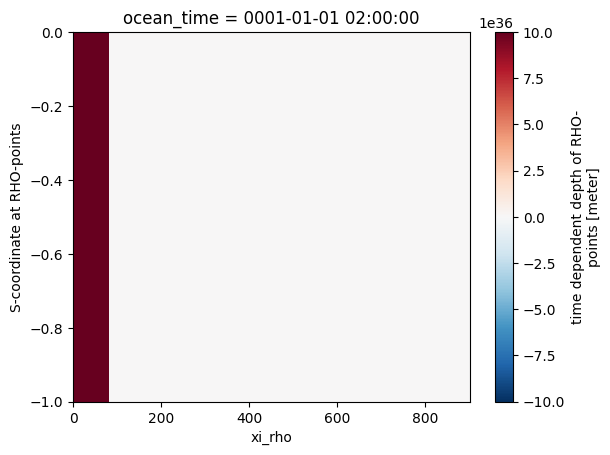

In [242]:
ds.z_rho[:,500,:].plot()

Text(0.5, 0, 'Cross Shore Distance [m]')

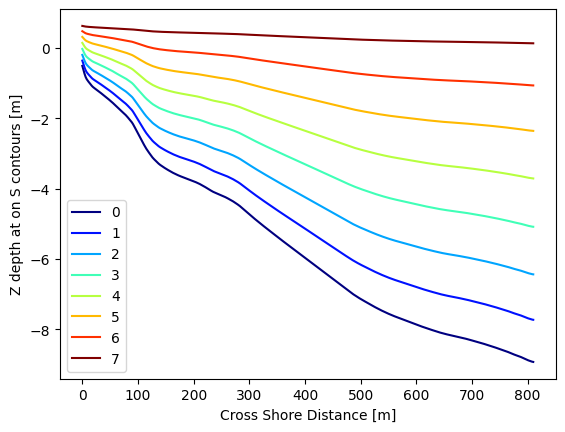

In [294]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

colors = plt.cm.jet(np.linspace(0,1,8))
cm = LinearSegmentedColormap('x', colors, 7)

for i in range(8):
    plt.plot(dss.z_rho[i, 500, 90:].values.T, c=colors[i], label=i)
# plt.colorbar(ScalarMappable(cmap=cm, norm=plt.Normalize(0, 8 - 1)), ticks=np.arange(8), label='cycles', cax=plt.gca())
plt.legend()
plt.ylabel('Z depth at on S contours [m]')
plt.xlabel('Cross Shore Distance [m]')

In [255]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:          (tracer: 1, s_rho: 8, s_w: 9, eta_rho: 1001, xi_rho: 901,
                      eta_u: 1001, xi_u: 900, eta_v: 1000, xi_v: 901,
                      eta_psi: 1000, xi_psi: 900)
Coordinates:
  * s_rho            (s_rho) float64 64B -0.9375 -0.8125 ... -0.1875 -0.0625
  * s_w              (s_w) float64 72B -1.0 -0.875 -0.75 ... -0.25 -0.125 0.0
    x_rho            (eta_rho, xi_rho) float64 7MB 50.0 51.0 ... 949.0 950.0
    y_rho            (eta_rho, xi_rho) float64 7MB -1.2e+03 -1.2e+03 ... 1.8e+03
    x_u              (eta_u, xi_u) float64 7MB 50.5 51.5 52.5 ... 948.5 949.5
    y_u              (eta_u, xi_u) float64 7MB -1.2e+03 -1.2e+03 ... 1.8e+03
    x_v              (eta_v, xi_v) float64 7MB 50.0 51.0 52.0 ... 949.0 950.0
    y_v              (eta_v, xi_v) float64 7MB -1.198e+03 ... 1.798e+03
    x_psi            (eta_psi, xi_psi) float64 7MB 50.5 51.5 ... 948.5 949.5
    y_psi            (eta_psi, xi_psi) float64 7MB -1.198e+03 ... 1.798e+03
    ocean_time       object 8B 0001-01-01 02:00:00
Dimensions without coordinates: tracer, eta_rho, xi_rho, eta_u, xi_u, eta_v,
                                xi_v, eta_psi, xi_psi
Data variables: (12/137)
    ntimes           int32 4B 14401
    ndtfast          int32 4B 10
    dt               float64 8B 0.5
    dtfast           float64 8B 0.05
    dstart           object 8B 0001-01-01 00:00:00
    nHIS             int32 4B 3600
    ...               ...
    Dissip_wcap      (eta_rho, xi_rho) float64 7MB nan nan nan ... 0.0 0.0 0.0
    Dissip_roller    (eta_rho, xi_rho) float64 7MB nan nan nan ... 0.0 0.0 0.0
    rollA            (eta_rho, xi_rho) float64 7MB nan nan nan ... 0.0 0.0 0.0
    zetaw            (eta_rho, xi_rho) float64 7MB nan nan ... -6.926e-92
    qsp              (eta_rho, xi_rho) float64 7MB nan nan ... -1.3e-49 -1.3e-49
    bh               (eta_rho, xi_rho) float64 7MB nan nan ... -9.456e-66
Attributes: (12/26)
    file:              ./output/ocean_dunex_his.nc
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS/TOMS history file
    title:             DUNEX
    var_info:          /gscratch/derakhti/shared/COAWST/ROMS/External/varinfo...
    ...                ...
    compiler_command:  /sw/ompi/4.1.0/bin/mpif90
    compiler_flags:    -frepack-arrays -O3 -ffast-math -O3 -ftree-vectorize -...
    tiling:            005x005
    history:           ROMS/TOMS, Version 3.8, Monday - May 27, 2024 - 10:31:...
    ana_file:          ROMS/Functionals/ana_btflux.h, ROMS/Functionals/ana_in...
    CPP_options:       DUNEX, ANA_BSFLUX, ANA_BTFLUX, ANA_INITIAL, ANA_SEDIME...